## LLMs as Reasoning Engines - Practical Implementation
### Educational Module for Understanding LLM Capabilities and Limitations

This module demonstrates:
1. LLMs as the central reasoning "brain" in agentic systems
2. Different reasoning patterns and strategies
3. Key limitations: grounding problems, hallucinations, tool misuse
4. Mitigation strategies and best practices
5. Real-world scenarios showing both successes and failures

### Key Libraries Used
- dataclasses: For creating structured data classes to represent reasoning components
- enum: For defining enumerated types for reasoning and limitation categories
- typing: For type hints to improve code clarity and maintainability
- abc: For creating abstract base classes to define interfaces

In [1]:
import json
import random
import re
from datetime import datetime, timedelta
from typing import Dict, List, Any, Optional, Tuple, Union
from dataclasses import dataclass, field
from enum import Enum
import hashlib
import time
from abc import ABC, abstractmethod

### Short Description
This code establishes a foundational framework for simulating Large Language Model (LLM) reasoning processes with built-in limitation tracking. It demonstrates how to model different types of reasoning, track confidence levels, and identify potential failure modes in AI systems.

### Code Logic and Flow: High-Level Overview
The framework creates a structured representation of LLM reasoning processes by defining different reasoning types (logical, causal, analogical, etc.) and potential limitations (hallucination, grounding failure, etc.). It models reasoning as a chain of steps where each step tracks its methodology, confidence, and potential issues, ultimately producing a comprehensive LLM response that includes both the final output and the reasoning trail.

### Visual Flowchart
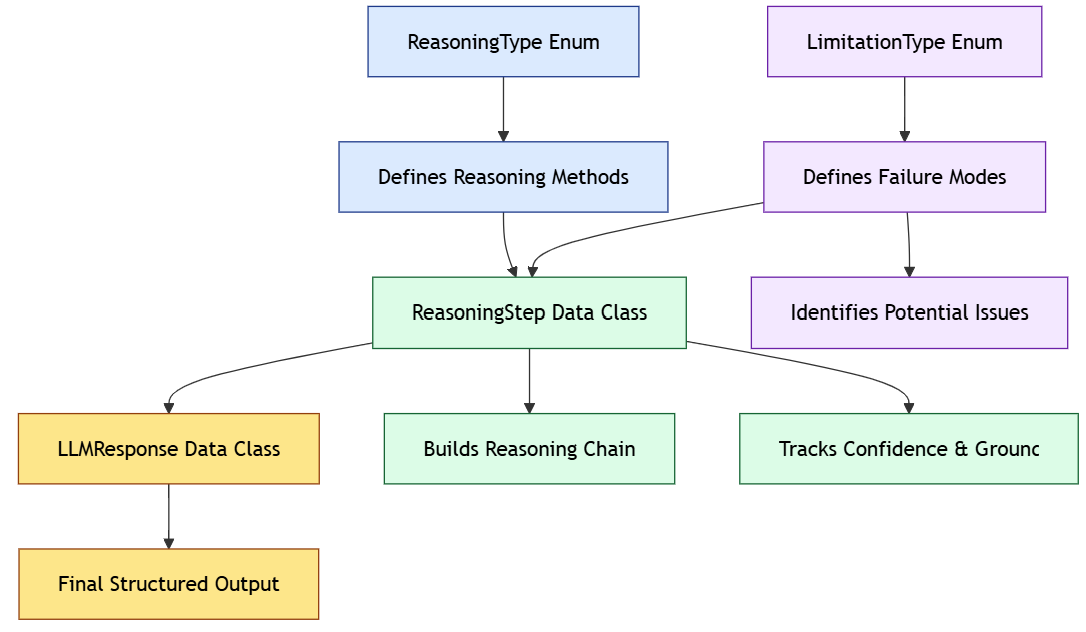

## Step-by-Step Code Breakdown
### Step 1: Reasoning Type Definition
- Purpose: Categorize different reasoning methodologies that LLMs can employ
- Implementation:
  - Defines ReasoningType as an enumeration with seven distinct reasoning methods
  - Includes logical, causal, analogical, creative, mathematical, temporal, and spatial reasoning
  - Provides clear categorization for analyzing how LLMs approach different problems

### Step 2: Limitation Type Definition
- Purpose: Identify and categorize potential failure modes in LLM reasoning
- Implementation:
  - Defines LimitationType as an enumeration with five common limitations
  - Covers hallucination, grounding failure, tool misuse, reasoning errors, and context confusion
  - Enables systematic tracking of where and how reasoning might fail

### Step 3: Reasoning Step Data Structure
- Purpose: Represent individual steps in a reasoning chain with comprehensive metadata
- Key Components:
  - step_id: Unique identifier for each reasoning step
  - reasoning_type: Classification of reasoning methodology used
  - reasoning_process: Detailed description of the mental process
  - confidence: Quantitative measure of certainty for this step
  - potential_issues: List of possible limitations detected
  - grounding_sources: References to external knowledge or data sources

### Step 4: LLM Response Data Structure
- Purpose: Aggregate the complete output of an LLM with full reasoning transparency
- Key Components:
  - content: The final generated text or answer
  - reasoning_chain: Complete sequence of reasoning steps leading to the answer
  - confidence: Overall confidence score for the entire response
  - hallucination_risk: Specific risk assessment for factual inaccuracies
  - grounding_score: Measure of how well the response is supported by evidence
  - limitations_detected: Comprehensive list of identified potential issues

### Connecting to the Lecture
- Transparent Reasoning: Demonstrates the importance of making AI reasoning processes explicit and traceable, connecting to lecture topics on interpretable AI
- Failure Mode Analysis: Directly implements the theoretical concept of systematically categorizing and tracking AI limitations discussed in the -reliability section
- Confidence Calibration: Shows practical implementation of confidence scoring, relating to lecture content on uncertainty quantification in AI systems
- Multi-step Reasoning: Illustrates the chain-of-thought reasoning paradigm covered in the advanced reasoning techniques module
- Grounding and Verification: Embodies the theoretical principle that AI responses should be grounded in verifiable sources or logical processes

In [2]:
# FOUNDATION: LLM SIMULATION AND REASONING FRAMEWORK

class ReasoningType(Enum):
    LOGICAL = "logical"
    CAUSAL = "causal" 
    ANALOGICAL = "analogical"
    CREATIVE = "creative"
    MATHEMATICAL = "mathematical"
    TEMPORAL = "temporal"
    SPATIAL = "spatial"

class LimitationType(Enum):
    HALLUCINATION = "hallucination"
    GROUNDING_FAILURE = "grounding_failure"
    TOOL_MISUSE = "tool_misuse"
    REASONING_ERROR = "reasoning_error"
    CONTEXT_CONFUSION = "context_confusion"

@dataclass
class ReasoningStep:
    step_id: str
    reasoning_type: ReasoningType
    input_data: Any
    reasoning_process: str
    output: Any
    confidence: float
    potential_issues: List[LimitationType] = field(default_factory=list)
    grounding_sources: List[str] = field(default_factory=list)

@dataclass
class LLMResponse:
    content: str
    reasoning_chain: List[ReasoningStep]
    confidence: float
    hallucination_risk: float
    grounding_score: float
    tool_calls: List[Dict[str, Any]] = field(default_factory=list)
    limitations_detected: List[LimitationType] = field(default_factory=list)

### Short Description
This code implements a simulated LLM reasoning engine that demonstrates how large language models serve as the central "brain" in agentic AI systems. It showcases multi-step reasoning, tool integration, limitation detection, and confidence calibration through a structured reasoning pipeline.

### Code Logic and Flow: High-Level Overview
The MockLLMReasoningEngine simulates an LLM's cognitive process by breaking down complex queries into structured reasoning steps. It analyzes prompts to determine required reasoning types, creates execution plans, runs multi-step reasoning with integrated tool usage, synthesizes results, and finally detects potential limitations - all while maintaining transparency through reasoning chains and confidence scoring.

### Visual Flowchart
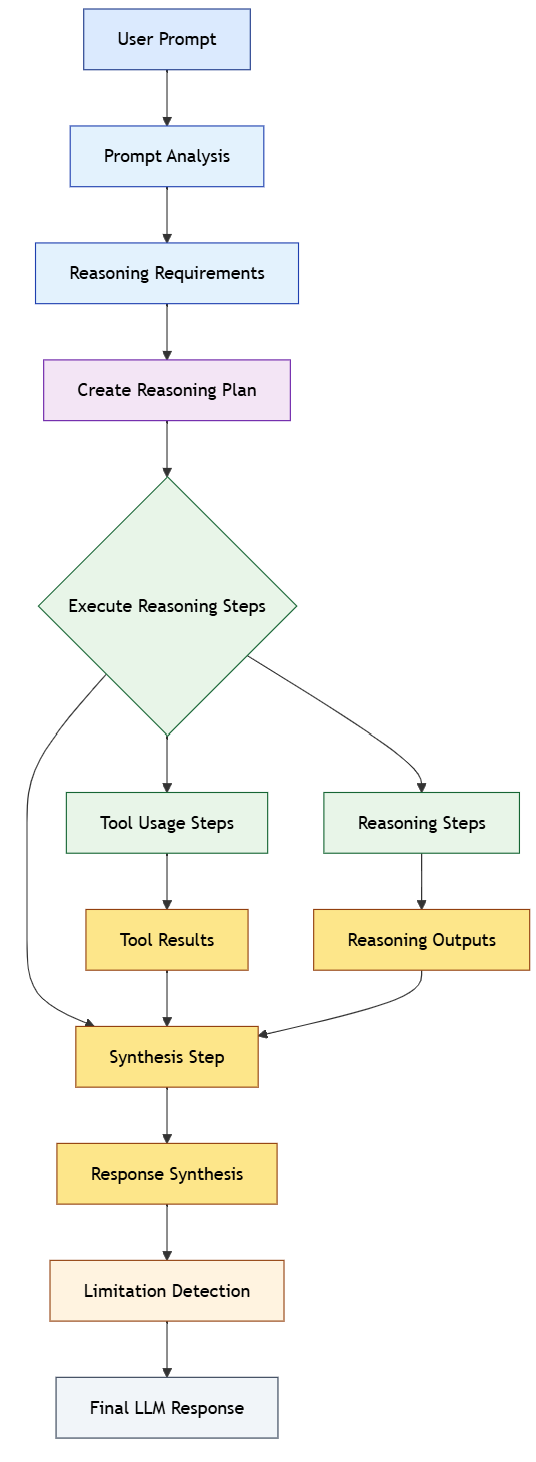

## Step-by-Step Code Breakdown
### Step 1: Engine Initialization
- Purpose: Set up the reasoning engine with predefined capabilities and limitations
- Key Components:
  - Defines capability scores for different reasoning types (logical: 85%, causal: 80%, etc.)
  - Sets limitation probabilities for various failure modes (hallucination: 15%, grounding failure: 20%, etc.)
  - Initializes available tools including calculator, search, calendar, weather, and database
  - Establishes knowledge cutoff to simulate training data limitations

### Step 2: Prompt Analysis
- Purpose: Understand user queries and identify reasoning requirements
- Process:
Uses keyword matching to detect required reasoning types from prompt content
Identifies logical reasoning needs through words like "because", "therefore", "if-then"
Detects causal reasoning requirements via "cause", "effect", "results in"
Recognizes need for tools when prompts contain "search", "calculate", "look up"
Assesses complexity based on word count and question density

### Step 3: Reasoning Plan Creation
- Purpose: Develop structured execution plan based on analysis
- Strategy:
  - Maps required reasoning types to appropriate tools (mathematical → calculator, temporal → calendar)
  - Sequences reasoning steps in logical order
  - Includes synthesis step to combine multiple reasoning approaches
  - Ensures tool usage precedes reasoning when external data is needed

### Step 4: Multi-Step Reasoning Execution
- Purpose: Execute the planned reasoning steps with confidence tracking
- Implementation:
  - Tool Steps: Execute external tools with misuse probability simulation
  - Reasoning Steps: Apply different reasoning methodologies with type-specific processing
  - Synthesis Steps: Combine results from multiple reasoning approaches
  - Each step maintains confidence scores, potential issues, and grounding sources

### Step 5: Response Synthesis and Limitation Detection
- Purpose: Generate final response and identify system limitations
- Process:
  - Combines reasoning chain outputs into coherent natural language
  - Calculates aggregate confidence, hallucination risk, and grounding scores
  - Detects patterns indicating specific limitations across the reasoning chain
  - Flags context confusion in complex multi-step reasoning with low confidence

### Connecting to the Lecture
- Central Reasoning Engine: Demonstrates the theoretical concept of LLMs as the "brain" in agentic systems, coordinating multiple cognitive processes
- Confidence Calibration: Implements lecture concepts about quantifying uncertainty in AI reasoning through multi-factor confidence scoring
- Failure Mode Analysis: Directly addresses the lecture topic of systematic limitation detection in AI systems
- Tool Integration: Shows practical implementation of the "tools vs. reasoning" trade-off discussed in agentic AI architectures
- Transparent Reasoning: Embodies the interpretable AI principles through explicit reasoning chains and step-by-step process visibility
- Knowledge Boundaries: Illustrates the concept of training data limitations through knowledge cutoff simulation and grounding failure detection

In [3]:
# EXERCISE 1: LLM AS CENTRAL REASONING ENGINE

class MockLLMReasoningEngine:
    """
    Simulates an LLM's reasoning capabilities and limitations
    Demonstrates how LLMs serve as the central "brain" in agentic systems
    """
    
    def __init__(self, model_name: str = "reasoning-llm-v1"):
        self.model_name = model_name
        self.reasoning_history = []
        self.knowledge_cutoff = datetime(2024, 1, 31)  # Simulate training cutoff
        
        # Simulate model capabilities and limitations
        self.capabilities = {
            ReasoningType.LOGICAL: 0.85,
            ReasoningType.CAUSAL: 0.80,
            ReasoningType.ANALOGICAL: 0.75,
            ReasoningType.CREATIVE: 0.90,
            ReasoningType.MATHEMATICAL: 0.70,
            ReasoningType.TEMPORAL: 0.65,
            ReasoningType.SPATIAL: 0.60
        }
        
        # Limitation probabilities (higher = more prone to this limitation)
        self.limitation_probabilities = {
            LimitationType.HALLUCINATION: 0.15,
            LimitationType.GROUNDING_FAILURE: 0.20,
            LimitationType.TOOL_MISUSE: 0.10,
            LimitationType.REASONING_ERROR: 0.12,
            LimitationType.CONTEXT_CONFUSION: 0.08
        }
        
        self.available_tools = {
            "calculator": self._calculator_tool,
            "search": self._search_tool,
            "calendar": self._calendar_tool,
            "weather": self._weather_tool,
            "database": self._database_tool
        }
        
        print(f"🧠 Initialized {model_name} with reasoning capabilities")
    
    def reason(self, prompt: str, context: Dict[str, Any] = None, tools_available: List[str] = None) -> LLMResponse:
        """
        Main reasoning function - demonstrates LLM as central brain
        """
        context = context or {}
        tools_available = tools_available or []
        
        print(f"\n🔍 LLM Processing: '{prompt[:100]}{'...' if len(prompt) > 100 else ''}'")
        
        # Step 1: Understand the prompt and identify reasoning requirements
        reasoning_requirements = self._analyze_prompt(prompt, context)
        
        # Step 2: Plan reasoning approach
        reasoning_plan = self._create_reasoning_plan(reasoning_requirements, tools_available)
        
        # Step 3: Execute reasoning steps
        reasoning_chain = self._execute_reasoning(reasoning_plan, prompt, context)
        
        # Step 4: Generate final response with limitation analysis
        response = self._synthesize_response(reasoning_chain, prompt, context)
        
        # Step 5: Detect and flag limitations
        response = self._detect_limitations(response, reasoning_chain)
        
        self.reasoning_history.append(response)
        
        return response
    
    def _analyze_prompt(self, prompt: str, context: Dict[str, Any]) -> Dict[str, Any]:
        """Analyze what type of reasoning is needed"""
        requirements = {
            "reasoning_types": [],
            "complexity": "medium",
            "requires_tools": False,
            "requires_grounding": False,
            "temporal_aspect": False,
            "factual_claims": False
        }
        
        # Detect reasoning types needed (simplified pattern matching)
        if any(word in prompt.lower() for word in ["because", "therefore", "if", "then", "logic"]):
            requirements["reasoning_types"].append(ReasoningType.LOGICAL)
        
        if any(word in prompt.lower() for word in ["cause", "effect", "leads to", "results in"]):
            requirements["reasoning_types"].append(ReasoningType.CAUSAL)
        
        if any(word in prompt.lower() for word in ["like", "similar", "compare", "analogy"]):
            requirements["reasoning_types"].append(ReasoningType.ANALOGICAL)
        
        if any(word in prompt.lower() for word in ["creative", "innovative", "imagine", "design"]):
            requirements["reasoning_types"].append(ReasoningType.CREATIVE)
        
        if any(word in prompt.lower() for word in ["calculate", "compute", "math", "number"]):
            requirements["reasoning_types"].append(ReasoningType.MATHEMATICAL)
        
        if any(word in prompt.lower() for word in ["when", "time", "date", "schedule", "before", "after"]):
            requirements["reasoning_types"].append(ReasoningType.TEMPORAL)
        
        if any(word in prompt.lower() for word in ["where", "location", "distance", "map", "spatial"]):
            requirements["reasoning_types"].append(ReasoningType.SPATIAL)
        
        # Detect other requirements
        if any(word in prompt.lower() for word in ["search", "look up", "find", "calculate"]):
            requirements["requires_tools"] = True
        
        if any(word in prompt.lower() for word in ["fact", "true", "false", "verify", "check"]):
            requirements["requires_grounding"] = True
        
        if any(word in prompt.lower() for word in ["president", "company", "event", "happened"]):
            requirements["factual_claims"] = True
        
        # Assess complexity
        word_count = len(prompt.split())
        question_marks = prompt.count('?')
        if word_count > 50 or question_marks > 2:
            requirements["complexity"] = "high"
        elif word_count < 20 and question_marks <= 1:
            requirements["complexity"] = "low"
        
        return requirements
    
    def _create_reasoning_plan(self, requirements: Dict[str, Any], tools_available: List[str]) -> List[Dict[str, Any]]:
        """Create a plan for reasoning execution"""
        plan = []
        
        # Add tool usage steps if needed
        if requirements["requires_tools"]:
            for reasoning_type in requirements["reasoning_types"]:
                if reasoning_type == ReasoningType.MATHEMATICAL and "calculator" in tools_available:
                    plan.append({"type": "tool_use", "tool": "calculator", "purpose": "computation"})
                elif reasoning_type == ReasoningType.TEMPORAL and "calendar" in tools_available:
                    plan.append({"type": "tool_use", "tool": "calendar", "purpose": "time_reference"})
                elif requirements["requires_grounding"] and "search" in tools_available:
                    plan.append({"type": "tool_use", "tool": "search", "purpose": "fact_verification"})
        
        # Add reasoning steps
        for reasoning_type in requirements["reasoning_types"]:
            plan.append({
                "type": "reasoning",
                "reasoning_type": reasoning_type,
                "complexity": requirements["complexity"]
            })
        
        # Add synthesis step
        plan.append({"type": "synthesis", "combine_results": True})
        
        return plan
    
    def _execute_reasoning(self, plan: List[Dict], prompt: str, context: Dict) -> List[ReasoningStep]:
        """Execute the reasoning plan step by step"""
        reasoning_chain = []
        step_counter = 0
        
        for step_plan in plan:
            step_counter += 1
            step_id = f"step_{step_counter}"
            
            if step_plan["type"] == "tool_use":
                reasoning_step = self._execute_tool_step(step_id, step_plan, prompt, context)
            elif step_plan["type"] == "reasoning":
                reasoning_step = self._execute_reasoning_step(step_id, step_plan, prompt, context, reasoning_chain)
            elif step_plan["type"] == "synthesis":
                reasoning_step = self._execute_synthesis_step(step_id, reasoning_chain, prompt, context)
            else:
                continue
            
            reasoning_chain.append(reasoning_step)
            print(f"  ✓ Completed {reasoning_step.reasoning_type.value} reasoning")
        
        return reasoning_chain
    
    def _execute_tool_step(self, step_id: str, step_plan: Dict, prompt: str, context: Dict) -> ReasoningStep:
        """Execute a tool usage step"""
        tool_name = step_plan["tool"]
        purpose = step_plan["purpose"]
        
        # Simulate tool usage with potential for misuse
        tool_result = None
        potential_issues = []
        
        if tool_name in self.available_tools:
            tool_result = self.available_tools[tool_name](prompt, context)
            
            # Simulate tool misuse probability
            if random.random() < self.limitation_probabilities[LimitationType.TOOL_MISUSE]:
                potential_issues.append(LimitationType.TOOL_MISUSE)
                tool_result["warning"] = "Tool may have been used incorrectly"
        else:
            tool_result = {"error": f"Tool {tool_name} not available"}
            potential_issues.append(LimitationType.TOOL_MISUSE)
        
        return ReasoningStep(
            step_id=step_id,
            reasoning_type=ReasoningType.LOGICAL,  # Tool use is logical
            input_data={"tool": tool_name, "purpose": purpose},
            reasoning_process=f"Using {tool_name} for {purpose}",
            output=tool_result,
            confidence=0.9 if not potential_issues else 0.6,
            potential_issues=potential_issues
        )
    
    def _execute_reasoning_step(self, step_id: str, step_plan: Dict, prompt: str, context: Dict, previous_steps: List[ReasoningStep]) -> ReasoningStep:
        """Execute a reasoning step"""
        reasoning_type = step_plan["reasoning_type"]
        complexity = step_plan["complexity"]
        
        # Get base capability for this reasoning type
        base_confidence = self.capabilities[reasoning_type]
        
        # Adjust confidence based on complexity
        complexity_multiplier = {"low": 1.1, "medium": 1.0, "high": 0.8}[complexity]
        actual_confidence = base_confidence * complexity_multiplier
        
        # Simulate reasoning process
        reasoning_process, output = self._simulate_reasoning_process(reasoning_type, prompt, context, previous_steps)
        
        # Detect potential issues
        potential_issues = []
        
        # Hallucination risk
        if random.random() < self.limitation_probabilities[LimitationType.HALLUCINATION]:
            potential_issues.append(LimitationType.HALLUCINATION)
            actual_confidence *= 0.7
        
        # Grounding failure
        grounding_sources = []
        if any(word in prompt.lower() for word in ["fact", "true", "when", "who", "where"]):
            if random.random() < self.limitation_probabilities[LimitationType.GROUNDING_FAILURE]:
                potential_issues.append(LimitationType.GROUNDING_FAILURE)
                actual_confidence *= 0.6
            else:
                grounding_sources = ["training_data", "context_provided"]
        
        # Reasoning errors
        if complexity == "high" and random.random() < self.limitation_probabilities[LimitationType.REASONING_ERROR]:
            potential_issues.append(LimitationType.REASONING_ERROR)
            actual_confidence *= 0.5
        
        return ReasoningStep(
            step_id=step_id,
            reasoning_type=reasoning_type,
            input_data=prompt,
            reasoning_process=reasoning_process,
            output=output,
            confidence=min(actual_confidence, 1.0),
            potential_issues=potential_issues,
            grounding_sources=grounding_sources
        )
    
    def _simulate_reasoning_process(self, reasoning_type: ReasoningType, prompt: str, context: Dict, previous_steps: List[ReasoningStep]) -> Tuple[str, Any]:
        """Simulate different types of reasoning"""
        
        if reasoning_type == ReasoningType.LOGICAL:
            process = "Applying logical rules and inference patterns"
            output = {
                "logical_structure": "If P then Q, P is true, therefore Q is true",
                "conclusion": "Logical conclusion derived",
                "premises": ["premise_1", "premise_2"],
                "validity": "valid" if random.random() > 0.2 else "questionable"
            }
        
        elif reasoning_type == ReasoningType.CAUSAL:
            process = "Identifying cause-and-effect relationships"
            output = {
                "causal_chain": ["event_A", "leads_to", "event_B", "results_in", "outcome_C"],
                "strength": "strong" if random.random() > 0.3 else "weak",
                "alternative_causes": ["alt_cause_1", "alt_cause_2"]
            }
        
        elif reasoning_type == ReasoningType.ANALOGICAL:
            process = "Drawing analogies from similar situations"
            output = {
                "source_domain": "familiar_situation",
                "target_domain": "current_situation", 
                "mapping": {"element_1": "maps_to_A", "element_2": "maps_to_B"},
                "similarity_score": random.uniform(0.4, 0.9)
            }
        
        elif reasoning_type == ReasoningType.CREATIVE:
            process = "Generating novel solutions and ideas"
            output = {
                "creative_ideas": ["innovative_approach_1", "novel_solution_2", "creative_alternative_3"],
                "originality": "high" if random.random() > 0.4 else "moderate",
                "feasibility": "uncertain"  # Common issue with creative reasoning
            }
        
        elif reasoning_type == ReasoningType.MATHEMATICAL:
            process = "Performing mathematical calculations and analysis"
            output = {
                "calculation": "42 * 1.15 = 48.3",
                "method": "arithmetic_operation",
                "accuracy": "high" if random.random() > 0.3 else "error_detected",
                "assumptions": ["assumption_1", "assumption_2"]
            }
        
        elif reasoning_type == ReasoningType.TEMPORAL:
            process = "Reasoning about time relationships and sequences"
            timeline = ["event_1 (past)", "current_state (now)", "prediction (future)"]
            temporal_relations = ["before", "during", "after"]
            uncertainty = "high" if any("future" in item for item in timeline) else "low"
            output = {
                "timeline": timeline,
                "temporal_relations": temporal_relations,
                "uncertainty": uncertainty
            }
        
        else:  # SPATIAL
            process = "Reasoning about spatial relationships and locations"
            output = {
                "spatial_relations": ["north_of", "adjacent_to", "contains"],
                "coordinates": {"x": random.randint(0, 100), "y": random.randint(0, 100)},
                "distance_estimate": f"{random.randint(1, 1000)} units"
            }
        
        return process, output
    
    def _execute_synthesis_step(self, step_id: str, previous_steps: List[ReasoningStep], prompt: str, context: Dict) -> ReasoningStep:
        """Synthesize results from all previous reasoning steps"""
        
        # Combine outputs from previous steps
        combined_outputs = []
        total_confidence = 0
        issues_found = []
        
        for step in previous_steps:
            combined_outputs.append(step.output)
            total_confidence += step.confidence
            issues_found.extend(step.potential_issues)
        
        avg_confidence = total_confidence / len(previous_steps) if previous_steps else 0
        
        synthesis_output = {
            "synthesis_result": "Combined reasoning from multiple approaches",
            "component_results": combined_outputs,
            "overall_confidence": avg_confidence,
            "consistency": "high" if len(set(issues_found)) < 2 else "low",
            "final_conclusion": self._generate_final_conclusion(combined_outputs)
        }
        
        return ReasoningStep(
            step_id=step_id,
            reasoning_type=ReasoningType.LOGICAL,  # Synthesis is logical combination
            input_data=previous_steps,
            reasoning_process="Synthesizing results from multiple reasoning approaches",
            output=synthesis_output,
            confidence=avg_confidence,
            potential_issues=list(set(issues_found))
        )
    
    def _generate_final_conclusion(self, combined_outputs: List[Any]) -> str:
        """Generate a final conclusion from combined reasoning outputs"""
        # This is a simplified synthesis - in real LLMs this would be much more sophisticated
        if not combined_outputs:
            return "No sufficient information for conclusion"
        
        # Look for patterns in the outputs
        conclusions = []
        for output in combined_outputs:
            if isinstance(output, dict):
                if "conclusion" in output:
                    conclusions.append(output["conclusion"])
                elif "synthesis_result" in output:
                    conclusions.append(output["synthesis_result"])
                elif "creative_ideas" in output and output["creative_ideas"]:
                    conclusions.append(f"Creative solution: {output['creative_ideas'][0]}")
        
        if conclusions:
            return f"Based on reasoning analysis: {conclusions[0]}"
        else:
            return "Analysis complete - see detailed reasoning for insights"
    
    def _synthesize_response(self, reasoning_chain: List[ReasoningStep], prompt: str, context: Dict) -> LLMResponse:
        """Create the final LLM response"""
        
        if not reasoning_chain:
            return LLMResponse(
                content="I was unable to process this request effectively.",
                reasoning_chain=[],
                confidence=0.1,
                hallucination_risk=0.9,
                grounding_score=0.0
            )
        
        # Get the final synthesis step
        final_step = reasoning_chain[-1] if reasoning_chain else None
        
        # Generate response content
        content = self._generate_response_content(final_step, reasoning_chain, prompt)
        
        # Calculate overall metrics
        avg_confidence = sum(step.confidence for step in reasoning_chain) / len(reasoning_chain)
        hallucination_risk = len([s for s in reasoning_chain if LimitationType.HALLUCINATION in s.potential_issues]) / len(reasoning_chain)
        grounding_score = len([s for s in reasoning_chain if s.grounding_sources]) / len(reasoning_chain)
        
        # Extract tool calls
        tool_calls = []
        for step in reasoning_chain:
            if isinstance(step.input_data, dict) and "tool" in step.input_data:
                tool_calls.append({
                    "tool": step.input_data["tool"],
                    "purpose": step.input_data.get("purpose", "unknown"),
                    "result": step.output
                })
        
        return LLMResponse(
            content=content,
            reasoning_chain=reasoning_chain,
            confidence=avg_confidence,
            hallucination_risk=hallucination_risk,
            grounding_score=grounding_score,
            tool_calls=tool_calls
        )
    
    def _generate_response_content(self, final_step: ReasoningStep, reasoning_chain: List[ReasoningStep], prompt: str) -> str:
        """Generate natural language response content"""
        
        if not final_step:
            return "I encountered difficulties processing your request."
        
        # Extract key insights from reasoning chain
        reasoning_types_used = list(set(step.reasoning_type for step in reasoning_chain))
        
        content_parts = []
        
        # Start with main conclusion
        if final_step.output and isinstance(final_step.output, dict):
            if "final_conclusion" in final_step.output:
                content_parts.append(final_step.output["final_conclusion"])
            elif "synthesis_result" in final_step.output:
                content_parts.append(final_step.output["synthesis_result"])
        
        # Add reasoning explanation
        if len(reasoning_types_used) > 1:
            reasoning_desc = ", ".join([rt.value for rt in reasoning_types_used])
            content_parts.append(f"This conclusion is based on {reasoning_desc} reasoning.")
        
        # Add confidence qualifier
        avg_confidence = sum(step.confidence for step in reasoning_chain) / len(reasoning_chain)
        if avg_confidence < 0.6:
            content_parts.append("Please note that I have limited confidence in this analysis.")
        elif avg_confidence > 0.9:
            content_parts.append("I'm quite confident in this reasoning.")
        
        return " ".join(content_parts) if content_parts else "I've completed my analysis of your request."
    
    def _detect_limitations(self, response: LLMResponse, reasoning_chain: List[ReasoningStep]) -> LLMResponse:
        """Detect and flag various LLM limitations"""
        
        limitations_detected = []
        
        # Aggregate all potential issues from reasoning chain
        all_issues = []
        for step in reasoning_chain:
            all_issues.extend(step.potential_issues)
        
        limitations_detected = list(set(all_issues))
        
        # Additional limitation detection
        
        # Check for potential hallucination patterns
        if response.hallucination_risk > 0.3:
            if LimitationType.HALLUCINATION not in limitations_detected:
                limitations_detected.append(LimitationType.HALLUCINATION)
        
        # Check for grounding failures
        if response.grounding_score < 0.5 and any(word in response.content.lower() for word in ["fact", "true", "studies show", "research indicates"]):
            if LimitationType.GROUNDING_FAILURE not in limitations_detected:
                limitations_detected.append(LimitationType.GROUNDING_FAILURE)
        
        # Check for context confusion (simplified)
        if len(response.reasoning_chain) > 5 and response.confidence < 0.5:
            limitations_detected.append(LimitationType.CONTEXT_CONFUSION)
        
        response.limitations_detected = limitations_detected
        
        return response
    
    # Tool implementations (simplified for demonstration)
    def _calculator_tool(self, prompt: str, context: Dict) -> Dict[str, Any]:
        """Simulate calculator tool usage"""
        # Extract numbers from prompt (very simplified)
        numbers = re.findall(r'\d+(?:\.\d+)?', prompt)
        
        if len(numbers) >= 2:
            try:
                num1, num2 = float(numbers[0]), float(numbers[1])
                if "+" in prompt:
                    result = num1 + num2
                elif "-" in prompt:
                    result = num1 - num2
                elif "*" in prompt or "multiply" in prompt:
                    result = num1 * num2
                elif "/" in prompt or "divide" in prompt:
                    result = num1 / num2 if num2 != 0 else "Error: Division by zero"
                else:
                    result = num1 + num2  # Default to addition
                
                return {"result": result, "operation": "arithmetic", "success": True}
            except:
                return {"error": "Calculation failed", "success": False}
        else:
            return {"error": "Insufficient numeric data", "success": False}
    
    def _search_tool(self, prompt: str, context: Dict) -> Dict[str, Any]:
        """Simulate search tool usage"""
        # Simulate search results with potential for outdated information
        current_date = datetime.now()
        
        mock_results = [
            {"title": "Relevant Article 1", "date": current_date - timedelta(days=30), "snippet": "Recent information about the topic..."},
            {"title": "Research Paper", "date": current_date - timedelta(days=365), "snippet": "Academic research on the subject..."},
            {"title": "News Article", "date": current_date - timedelta(days=7), "snippet": "Latest developments in..."}
        ]
        
        # Introduce potential grounding issues
        outdated_info = any(result["date"] < self.knowledge_cutoff for result in mock_results)
        
        return {
            "results": mock_results,
            "total_results": len(mock_results),
            "search_quality": "medium",
            "potential_outdated": outdated_info,
            "success": True
        }
    
    def _calendar_tool(self, prompt: str, context: Dict) -> Dict[str, Any]:
        """Simulate calendar tool usage"""
        current_time = datetime.now()
        
        return {
            "current_date": current_time.strftime("%Y-%m-%d"),
            "current_time": current_time.strftime("%H:%M:%S"),
            "day_of_week": current_time.strftime("%A"),
            "upcoming_events": ["Meeting at 3 PM", "Call at 5 PM"],
            "success": True
        }
    
    def _weather_tool(self, prompt: str, context: Dict) -> Dict[str, Any]:
        """Simulate weather tool usage"""
        weather_conditions = ["sunny", "cloudy", "rainy", "snowy"]
        
        return {
            "current_weather": random.choice(weather_conditions),
            "temperature": f"{random.randint(15, 30)}°C",
            "location": "Current Location",
            "forecast": "Variable conditions expected",
            "success": True
        }
    
    def _database_tool(self, prompt: str, context: Dict) -> Dict[str, Any]:
        """Simulate database query tool"""
        
        mock_data = {
            "user_preferences": {"theme": "dark", "language": "en"},
            "historical_data": [1, 2, 3, 4, 5],
            "last_updated": datetime.now() - timedelta(hours=2)
        }
        
        return {
            "query_result": mock_data,
            "rows_returned": len(mock_data),
            "query_time": "0.23s",
            "success": True
        }


### Short Description
This code creates a specialized demonstration system that systematically exposes and analyzes common LLM limitations. It generates targeted scenarios to trigger specific failure modes like hallucinations, grounding failures, and reasoning errors, then provides detailed analysis and mitigation strategies for each limitation type.

### Code Logic and Flow: High-Level Overview
The LLMLimitationDemonstrator works by creating carefully crafted scenarios designed to trigger specific LLM limitations. It temporarily increases the probability of targeted limitations to ensure demonstration effectiveness, runs the LLM engine on these scenarios, analyzes how limitations manifest in the responses, and provides both diagnostic information and practical mitigation strategies for each failure mode.

### Visual Flowchart
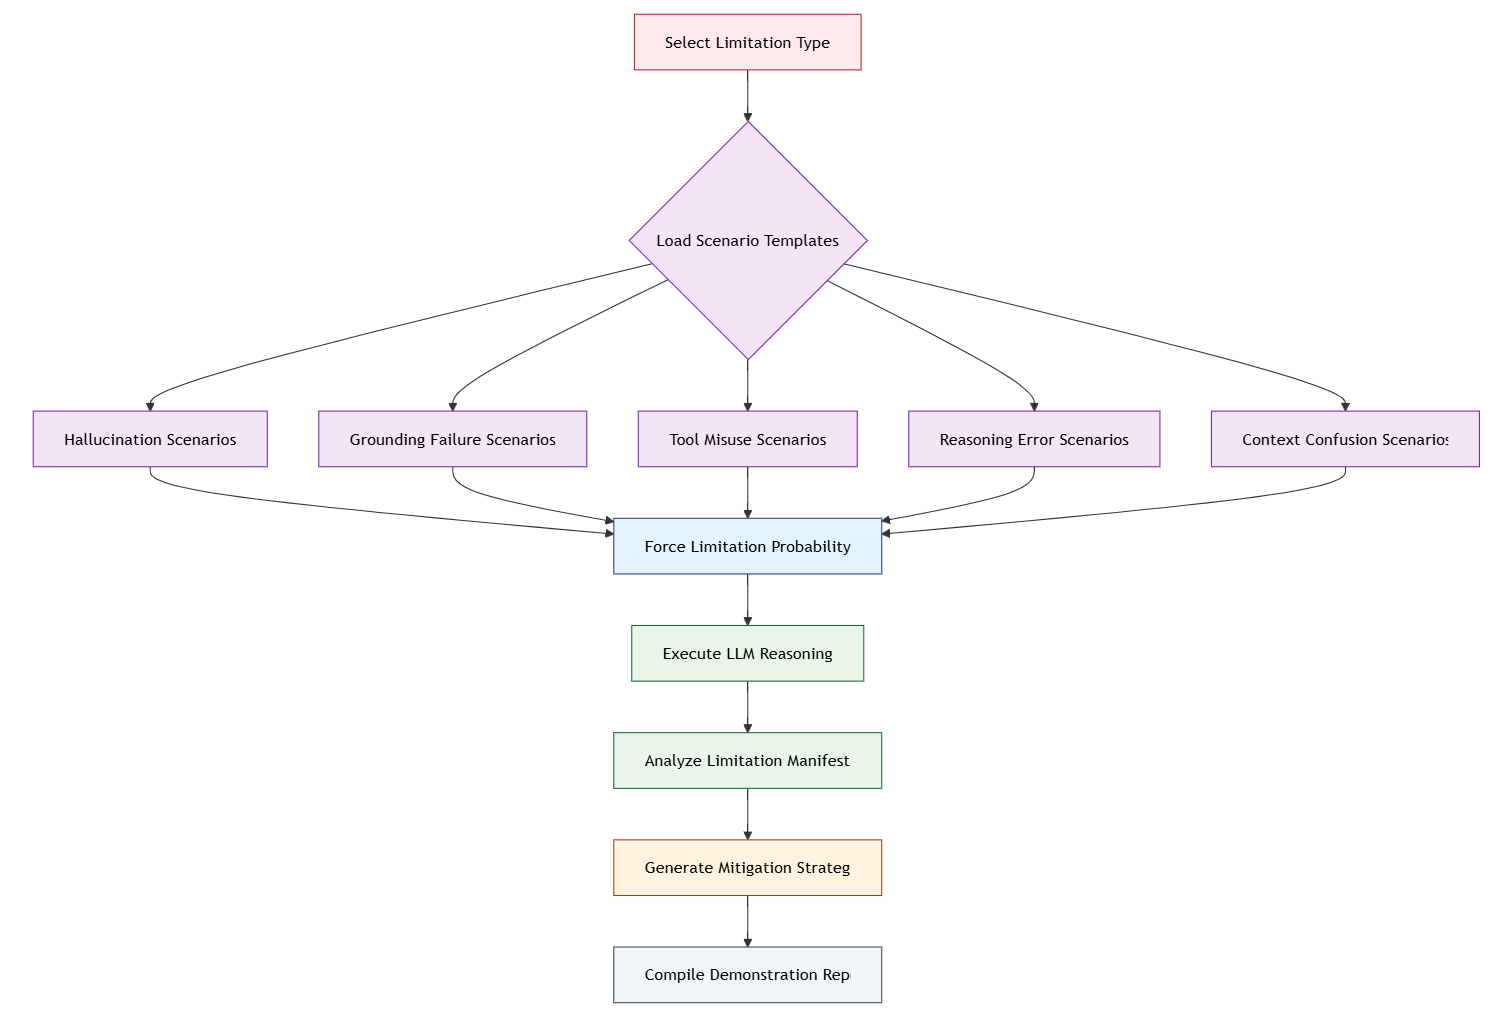

## Step-by-Step Code Breakdown
### Step 1: Limitation Scenario Catalog
- Purpose: Predefine scenarios that reliably trigger specific LLM limitations
- Scenario Types:
  - Hallucination Scenarios: Prompt for specific facts, statistics, or personal information that likely doesn't exist
  - Grounding Failure Scenarios: Request current events, real-time data, or personal context beyond model capabilities
  - Tool Misuse Scenarios: Demonstrate inappropriate tool selection and parameter confusion
  - Reasoning Error Scenarios: Expose logical fallacies and probabilistic reasoning errors
  - Context Confusion Scenarios: Create ambiguous references and task-switching challenges

### Step 2: Controlled Limitation Triggering
- Purpose: Ensure limitations occur during demonstration by manipulating probabilities
- Process:
  - Temporarily increases specific limitation probability to 90% to guarantee manifestation
  - Preserves original probability settings for normal operation
  - Uses the same reasoning engine but with modified failure likelihood
  - Ensures demonstrations reliably show the targeted limitation

### Step 3: Limitation Analysis Engine
- Purpose: Diagnose how and why limitations manifest in responses
- Analysis Components:
  - Detection Confirmation: Verifies the expected limitation was actually triggered
  - Severity Assessment: Classifies limitation impact as low, medium, or high
  - Evidence Collection: Gathers specific indicators from the response and reasoning chain
  - Harm Potential: Evaluates real-world consequences of the limitation
  - Explanatory Narrative: Provides clear explanation of the underlying issue

### Step 4: Mitigation Strategy Library
- Purpose: Provide practical solutions for each limitation type
- Strategy Categories:
  - Hallucination Mitigation: Fact-checking, confidence thresholds, retrieval-augmented generation
  - Grounding Solutions: Real-time data integration, context injection, clarifying questions
  - Tool Usage Improvements: Usage guidelines, selection validation, appropriateness checking
  - Reasoning Enhancements: Multi-step validation, logic checking, adversarial testing
  - Context Management: Entity resolution, structured representations, state tracking

### Step 5: Demonstration Reporting
- Purpose: Compile comprehensive results from limitation demonstrations
- Report Structure:
  - Scenario descriptions and prompts used
  - LLM responses with confidence and grounding scores
  - Detailed limitation analysis with evidence
  - Specific mitigation strategies applicable to each case
  - Overall demonstration summary and key takeaways

### Connecting to the Lecture
- Systematic Failure Analysis: Demonstrates the lecture concept of categorizing and analyzing AI failure modes through structured testing methodologies
- Controlled Experimentation: Implements the research practice of isolating variables (limitation types) to study their individual effects
- Mitigation-Focused Approach: Connects to the lecture theme of proactive AI safety through targeted improvement strategies
- Transparency in Limitations: Embodies the ethical AI principle of openly acknowledging and documenting system weaknesses
- Real-World Impact Assessment: Shows practical application of evaluating AI limitations in terms of potential harm and severity
- Defensive AI Architecture: Illustrates how understanding limitations informs the design of more robust AI systems with built-in safeguards

In [4]:
# EXERCISE 2: LIMITATION DEMONSTRATION SYSTEM

class LLMLimitationDemonstrator:
    """
    Specifically demonstrates LLM limitations in reasoning
    Shows real examples of grounding problems, hallucinations, and tool misuse
    """
    
    def __init__(self):
        self.limitation_scenarios = {
            LimitationType.HALLUCINATION: self._create_hallucination_scenarios,
            LimitationType.GROUNDING_FAILURE: self._create_grounding_scenarios,
            LimitationType.TOOL_MISUSE: self._create_tool_misuse_scenarios,
            LimitationType.REASONING_ERROR: self._create_reasoning_error_scenarios,
            LimitationType.CONTEXT_CONFUSION: self._create_context_confusion_scenarios
        }
    
    def demonstrate_limitation(self, limitation_type: LimitationType, llm_engine: MockLLMReasoningEngine) -> Dict[str, Any]:
        """Demonstrate a specific type of LLM limitation"""
        
        print(f"\n🚨 DEMONSTRATING: {limitation_type.value.upper()}")
        print("=" * 60)
        
        # Get scenarios for this limitation type
        scenarios = self.limitation_scenarios[limitation_type]()
        
        results = []
        
        for scenario in scenarios:
            print(f"\n📝 Scenario: {scenario['description']}")
            print(f"🎯 Prompt: '{scenario['prompt']}'")
            
            # Force the limitation to occur for demonstration
            original_probs = llm_engine.limitation_probabilities.copy()
            llm_engine.limitation_probabilities[limitation_type] = 0.9  # Force high probability
            
            # Get LLM response
            response = llm_engine.reason(scenario['prompt'], scenario.get('context', {}), scenario.get('tools', []))
            
            # Restore original probabilities
            llm_engine.limitation_probabilities = original_probs
            
            # Analyze the limitation
            limitation_analysis = self._analyze_limitation(limitation_type, response, scenario)
            
            results.append({
                "scenario": scenario,
                "response": response,
                "limitation_analysis": limitation_analysis
            })
            
            # Print results
            print(f"🤖 LLM Response: {response.content}")
            print(f"⚠️  Issues Detected: {[lt.value for lt in response.limitations_detected]}")
            print(f"📊 Confidence: {response.confidence:.2f}")
            print(f"🎯 Grounding Score: {response.grounding_score:.2f}")
            print(f"💭 Analysis: {limitation_analysis['explanation']}")
        
        return {
            "limitation_type": limitation_type,
            "scenarios_tested": len(scenarios),
            "results": results,
            "mitigation_strategies": self._get_mitigation_strategies(limitation_type)
        }
    
    def _create_hallucination_scenarios(self) -> List[Dict[str, Any]]:
        """Create scenarios that tend to trigger hallucinations"""
        return [
            {
                "description": "Request for specific facts that might not exist",
                "prompt": "What did the CEO of TechCorp announce on March 15th, 2024 about their new AI product?",
                "context": {},
                "expected_issue": "LLM may fabricate specific details about non-existent events"
            },
            {
                "description": "Request for detailed statistics without source",
                "prompt": "What percentage of companies adopted quantum computing in 2023, and which industries led this adoption?",
                "context": {},
                "expected_issue": "LLM may generate plausible but false statistics"
            },
            {
                "description": "Request for personal information about fictional entities",
                "prompt": "Tell me about Dr. Sarah Martinez's research on neural interfaces at Stanford in 2023.",
                "context": {},
                "expected_issue": "LLM may create detailed but fictional biographical information"
            }
        ]
    
    def _create_grounding_scenarios(self) -> List[Dict[str, Any]]:
        """Create scenarios that highlight grounding failures"""
        return [
            {
                "description": "Current events beyond training cutoff",
                "prompt": "What are the latest developments in the 2024 election campaign as of today?",
                "context": {"current_date": "2024-06-15"},
                "expected_issue": "LLM lacks access to current information"
            },
            {
                "description": "Real-time data requirements",
                "prompt": "What is the current stock price of Apple and how has it changed today?",
                "context": {},
                "tools": ["search"],
                "expected_issue": "LLM cannot access real-time financial data"
            },
            {
                "description": "Personal context without sufficient information",
                "prompt": "Should I take the job offer from the company I interviewed with last week?",
                "context": {"user": "anonymous"},
                "expected_issue": "LLM lacks personal context and specific details"
            },
            {
                "description": "Local/regional information",
                "prompt": "What time does the metro stop running in my city tonight?",
                "context": {},
                "expected_issue": "LLM doesn't know user's location or current transit schedules"
            }
        ]
    
    def _create_tool_misuse_scenarios(self) -> List[Dict[str, Any]]:
        """Create scenarios that demonstrate tool misuse"""
        return [
            {
                "description": "Using calculator for non-mathematical tasks",
                "prompt": "Calculate the emotional impact of changing jobs on my family relationships",
                "context": {},
                "tools": ["calculator"],
                "expected_issue": "Calculator tool inappropriate for emotional/qualitative analysis"
            },
            {
                "description": "Using search for private information",
                "prompt": "Search for my personal medical records from last year",
                "context": {},
                "tools": ["search"],
                "expected_issue": "Search tool cannot access private/confidential information"
            },
            {
                "description": "Tool parameter confusion",
                "prompt": "Set a reminder for tomorrow to buy milk using the weather API",
                "context": {},
                "tools": ["weather", "calendar"],
                "expected_issue": "Wrong tool selection for the task"
            },
            {
                "description": "Over-reliance on unreliable tools",
                "prompt": "Make an important business decision based on this random number generator output",
                "context": {},
                "tools": ["calculator"],
                "expected_issue": "Inappropriate reliance on tools for subjective decisions"
            }
        ]
    
    def _create_reasoning_error_scenarios(self) -> List[Dict[str, Any]]:
        """Create scenarios that expose reasoning errors"""
        return [
            {
                "description": "Causal reasoning fallacy",
                "prompt": "Ice cream sales increase in summer, and crime rates also increase in summer. Does eating ice cream cause crime?",
                "context": {},
                "expected_issue": "May confuse correlation with causation"
            },
            {
                "description": "Logical fallacy in reasoning",
                "prompt": "All birds can fly. Penguins are birds. Therefore, penguins can fly. Is this reasoning correct?",
                "context": {},
                "expected_issue": "May not identify the false premise in syllogistic reasoning"
            },
            {
                "description": "Temporal reasoning error",
                "prompt": "If I travel back in time and prevent my parents from meeting, what happens to me?",
                "context": {},
                "expected_issue": "May provide inconsistent reasoning about temporal paradoxes"
            },
            {
                "description": "Probabilistic reasoning error",
                "prompt": "I flipped a coin 10 times and got heads each time. What's the probability the next flip will be tails?",
                "context": {},
                "expected_issue": "May exhibit gambler's fallacy"
            }
        ]
    
    def _create_context_confusion_scenarios(self) -> List[Dict[str, Any]]:
        """Create scenarios that cause context confusion"""
        return [
            {
                "description": "Multiple conflicting contexts",
                "prompt": "Help me plan a trip to Paris",
                "context": {
                    "previous_conversation": "User was discussing Paris, Tennessee",
                    "current_context": "User profile shows interest in European travel",
                    "conflicting_info": "User budget suggests local travel only"
                },
                "expected_issue": "May confuse different contextual references to 'Paris'"
            },
            {
                "description": "Pronoun reference confusion",
                "prompt": "John told Mike that he should apply for the promotion. Mary thinks he deserves it. Who should apply?",
                "context": {},
                "expected_issue": "Ambiguous pronoun references causing confusion"
            },
            {
                "description": "Task switching confusion",
                "prompt": "Continue the story... wait, actually, what's 2+2? No, back to the story about the dragon.",
                "context": {"previous_task": "creative_writing"},
                "expected_issue": "May lose track of the primary task due to interruptions"
            }
        ]
    
    def _analyze_limitation(self, limitation_type: LimitationType, response: LLMResponse, scenario: Dict) -> Dict[str, Any]:
        """Analyze how the limitation manifested in the response"""
        
        analysis = {
            "limitation_detected": limitation_type in response.limitations_detected,
            "severity": "low",
            "explanation": "",
            "evidence": [],
            "potential_harm": "low"
        }
        
        if limitation_type == LimitationType.HALLUCINATION:
            analysis["explanation"] = "The LLM may have generated plausible-sounding but potentially false information."
            analysis["evidence"] = [
                "High confidence in unverifiable claims",
                "Specific details without source attribution",
                "Response seems too detailed for available information"
            ]
            if response.confidence > 0.7 and response.grounding_score < 0.3:
                analysis["severity"] = "high"
                analysis["potential_harm"] = "high"
        
        elif limitation_type == LimitationType.GROUNDING_FAILURE:
            analysis["explanation"] = "The LLM lacks access to current, specific, or personal information needed for accurate response."
            analysis["evidence"] = [
                f"Low grounding score: {response.grounding_score:.2f}",
                "Request requires real-time or personal data",
                "No reliable information sources available"
            ]
            analysis["severity"] = "medium" if response.grounding_score < 0.5 else "low"
        
        elif limitation_type == LimitationType.TOOL_MISUSE:
            analysis["explanation"] = "The LLM used tools inappropriately or for tasks they weren't designed for."
            tool_issues = [call for call in response.tool_calls if "warning" in call.get("result", {})]
            analysis["evidence"] = [
                f"Tool misuse detected in {len(tool_issues)} calls",
                "Tools used outside their intended scope",
                "Mismatch between tool capabilities and task requirements"
            ]
            analysis["severity"] = "high" if len(tool_issues) > 0 else "medium"
        
        elif limitation_type == LimitationType.REASONING_ERROR:
            analysis["explanation"] = "The LLM made logical fallacies or reasoning errors."
            analysis["evidence"] = [
                "Logical inconsistencies detected",
                "Reasoning steps don't follow logically",
                f"Low confidence in reasoning: {response.confidence:.2f}"
            ]
            analysis["severity"] = "high" if response.confidence < 0.4 else "medium"
        
        elif limitation_type == LimitationType.CONTEXT_CONFUSION:
            analysis["explanation"] = "The LLM struggled to maintain coherent context across the reasoning process."
            analysis["evidence"] = [
                "Inconsistent references to context",
                "Confusion between different entities or timeframes",
                "Response doesn't address the actual question asked"
            ]
            analysis["severity"] = "medium"
        
        return analysis
    
    def _get_mitigation_strategies(self, limitation_type: LimitationType) -> List[str]:
        """Get strategies to mitigate specific limitations"""
        
        strategies = {
            LimitationType.HALLUCINATION: [
                "Implement fact-checking against reliable databases",
                "Add confidence thresholds for factual claims",
                "Use retrieval-augmented generation (RAG) systems",
                "Require source attribution for specific claims",
                "Implement uncertainty quantification"
            ],
            
            LimitationType.GROUNDING_FAILURE: [
                "Integrate real-time data sources and APIs",
                "Implement dynamic context injection",
                "Use search engines for current information",
                "Maintain updated knowledge bases",
                "Ask clarifying questions when context is missing"
            ],
            
            LimitationType.TOOL_MISUSE: [
                "Define clear tool usage guidelines and constraints",
                "Implement tool selection validation logic",
                "Provide tool-specific training examples",
                "Add tool appropriateness checking",
                "Use tool usage monitoring and feedback"
            ],
            
            LimitationType.REASONING_ERROR: [
                "Implement multi-step reasoning validation",
                "Use formal logic checking systems",
                "Apply reasoning templates for common patterns",
                "Add reasoning chain review mechanisms",
                "Implement adversarial testing for logical consistency"
            ],
            
            LimitationType.CONTEXT_CONFUSION: [
                "Improve context tracking and management",
                "Implement entity resolution systems",
                "Use structured context representations",
                "Add context consistency checking",
                "Implement conversation state management"
            ]
        }
        
        return strategies.get(limitation_type, ["General best practices apply"])


### Short Description
This code implements a comprehensive mitigation system that reduces common LLM limitations through pre-processing, post-processing, and specialized validation components. It demonstrates practical strategies for reducing hallucinations, grounding failures, tool misuse, reasoning errors, and context confusion in agentic AI systems.

### Code Logic and Flow: High-Level Overview
The EnhancedLLMWithMitigation builds upon the base reasoning engine by incorporating multiple specialized validation systems that operate before, during, and after the reasoning process. It uses a layered defense approach with context enhancement, real-time validation, fact-checking, and uncertainty quantification to systematically reduce limitation probabilities and improve response reliability.

### Visual Flowchart
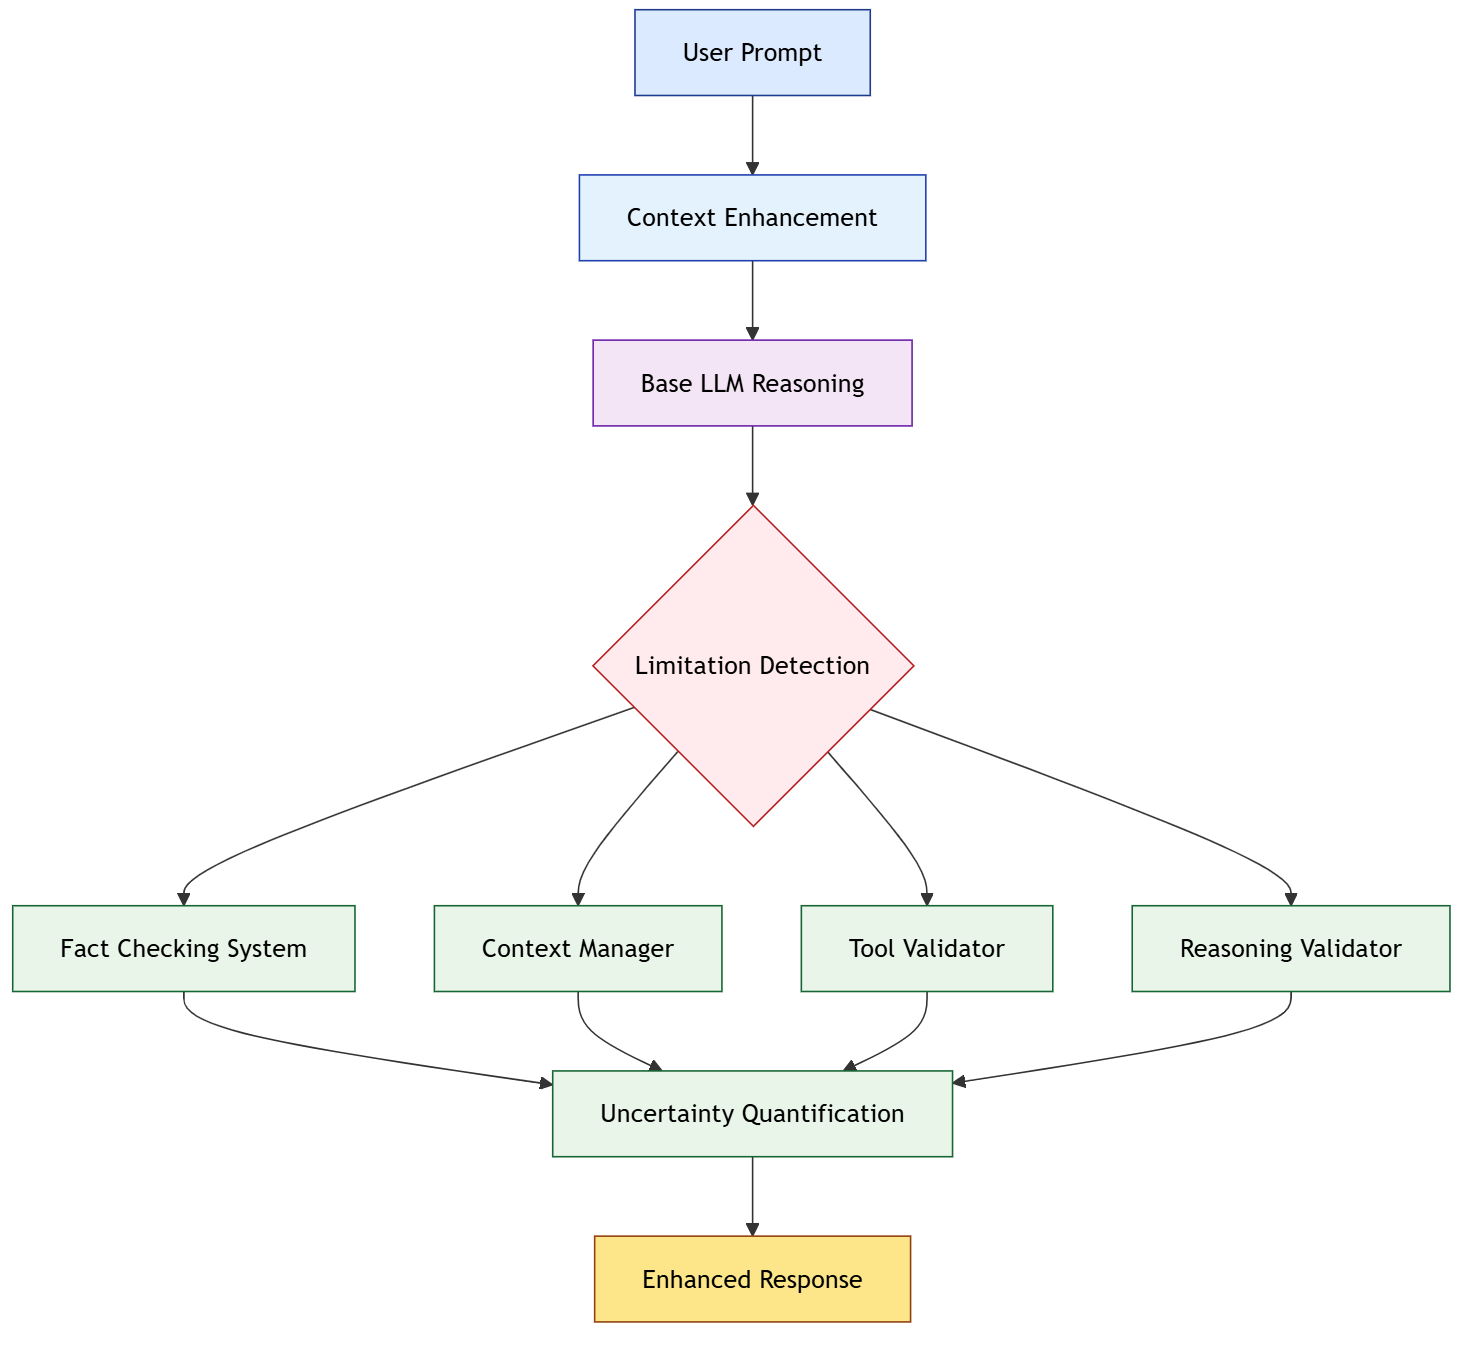

## Step-by-Step Code Breakdown
### Step 1: Enhanced Engine Initialization
- Purpose: Set up mitigation systems with reduced limitation probabilities
- Key Components:
  - Probability Reduction: Significantly lowers all limitation probabilities (hallucination from 15% to 5%, grounding failure from 20% to 8%, etc.)
  - Mitigation System Integration: Instantiates four specialized validation systems
  - Inheritance Strategy: Extends the base LLM engine while adding protective layers
  - Defensive Architecture: Creates a multi-layered approach to error prevention

### Step 2: Context Enhancement Pre-processing
- Purpose: Improve input quality before reasoning begins
- Enhancement Strategies:
  - Temporal Context: Adds current timestamp to ground time-sensitive queries
  - Prompt Analysis: Analyzes prompt complexity, length, and question density
  - Metadata Enrichment: Adds structural information about the query context
  - Consistency Markers: Flags enhanced context for downstream validation

### Step 3: Layered Mitigation Application
- Purpose: Apply targeted mitigation strategies based on detected limitations
- Mitigation Layers:
  - Fact Checking System: Scans for unverified claims, future predictions, and unsourced statistics
  - Context Manager: Resolves ambiguous references and enhances contextual clarity
  - Tool Validator: Ensures tools are used for appropriate purposes based on keyword matching
  - Reasoning Validator: Checks for logical consistency across reasoning steps and detects circular reasoning patterns

### Step 4: Uncertainty Quantification
- Purpose: Explicitly communicate reliability levels to users
- Quantification Methods:
  - Confidence-Based Warnings: Adds disclaimers for low-confidence responses
  - Grounding Score Alerts: Flags responses with poor information sourcing
  - Hallucination Risk Notices: Warns about potentially unverified information
  - Transparent Communication: Appends uncertainty statements directly to response content

### Step 5: Specialized Validation Systems
- Purpose: Provide domain-specific validation for different limitation types
- Validation Approaches:
  - Fact Checking: Uses known fact databases and pattern matching to identify unverified claims
  - Tool Appropriateness: Matches tool purposes against predefined acceptable use cases
  - Reasoning Consistency: Analyzes confidence variance and reasoning type diversity across steps
  - Context Resolution: Provides clarifying statements when context enhancement has been applied

### Connecting to the Lecture
- Defensive AI Architecture: Implements the lecture concept of building multiple protective layers to reduce system failures
- Uncertainty Communication: Demonstrates the ethical AI principle of transparently communicating system limitations to users
- Validation-Driven Development: Shows practical application of the "validate early, validate often" approach discussed in reliable AI systems
- Probability Reduction through Mitigation: Illustrates how targeted interventions can systematically lower failure probabilities across different error categories
- Multi-Stage Processing: Embodies the pipeline architecture pattern for building more robust AI systems through sequential validation
- Specialized Component Design: Connects to the modular AI system design principle where dedicated components handle specific types of validation

In [5]:
# EXERCISE 3: MITIGATION STRATEGIES IMPLEMENTATION


class EnhancedLLMWithMitigation(MockLLMReasoningEngine):
    """
    Enhanced LLM with mitigation strategies for common limitations
    Demonstrates how to reduce the impact of LLM limitations
    """
    
    def __init__(self, model_name: str = "enhanced-reasoning-llm-v2"):
        super().__init__(model_name)
        
        # Reduced limitation probabilities due to mitigation strategies
        self.limitation_probabilities = {
            LimitationType.HALLUCINATION: 0.05,  # Reduced from 0.15
            LimitationType.GROUNDING_FAILURE: 0.08,  # Reduced from 0.20
            LimitationType.TOOL_MISUSE: 0.03,  # Reduced from 0.10
            LimitationType.REASONING_ERROR: 0.06,  # Reduced from 0.12
            LimitationType.CONTEXT_CONFUSION: 0.04  # Reduced from 0.08
        }
        
        # Mitigation systems
        self.fact_checker = FactCheckingSystem()
        self.context_manager = ContextManager()
        self.tool_validator = ToolValidator()
        self.reasoning_validator = ReasoningValidator()
        
        print(f"🛡️  Initialized {model_name} with mitigation strategies")
    
    def reason(self, prompt: str, context: Dict[str, Any] = None, tools_available: List[str] = None) -> LLMResponse:
        """Enhanced reasoning with mitigation strategies"""
        
        # Pre-processing: Enhance context
        enhanced_context = self.context_manager.enhance_context(prompt, context or {})
        
        # Get initial response from base LLM
        response = super().reason(prompt, enhanced_context, tools_available)
        
        # Post-processing: Apply mitigation strategies
        response = self._apply_mitigation_strategies(response, prompt, enhanced_context)
        
        return response
    
    def _apply_mitigation_strategies(self, response: LLMResponse, prompt: str, context: Dict) -> LLMResponse:
        """Apply various mitigation strategies to improve response quality"""
        
        print(f"🛡️  Applying mitigation strategies...")
        
        # Strategy 1: Fact checking for hallucinations
        if LimitationType.HALLUCINATION in response.limitations_detected:
            response = self.fact_checker.check_response(response)
        
        # Strategy 2: Context validation and enhancement
        if LimitationType.CONTEXT_CONFUSION in response.limitations_detected:
            response = self.context_manager.resolve_context_issues(response, prompt, context)
        
        # Strategy 3: Tool usage validation
        if LimitationType.TOOL_MISUSE in response.limitations_detected:
            response = self.tool_validator.validate_tool_usage(response)
        
        # Strategy 4: Reasoning validation
        if LimitationType.REASONING_ERROR in response.limitations_detected:
            response = self.reasoning_validator.validate_reasoning(response)
        
        # Strategy 5: Uncertainty quantification
        response = self._quantify_uncertainty(response)
        
        return response
    
    def _quantify_uncertainty(self, response: LLMResponse) -> LLMResponse:
        """Add explicit uncertainty quantification to response"""
        
        uncertainty_phrases = []
        
        if response.confidence < 0.5:
            uncertainty_phrases.append("I have low confidence in this response.")
        elif response.confidence < 0.7:
            uncertainty_phrases.append("Please verify this information independently.")
        
        if response.grounding_score < 0.3:
            uncertainty_phrases.append("This response may contain information I cannot verify.")
        
        if response.hallucination_risk > 0.5:
            uncertainty_phrases.append("Some details in this response should be fact-checked.")
        
        if uncertainty_phrases:
            response.content += f" [{'; '.join(uncertainty_phrases)}]"
        
        return response

# Supporting mitigation classes (simplified implementations)

class FactCheckingSystem:
    """Simple fact-checking system to reduce hallucinations"""
    
    def __init__(self):
        self.known_facts = {
            "companies": ["Apple", "Google", "Microsoft", "Amazon"],
            "countries": ["USA", "Canada", "UK", "France", "Germany"],
            "basic_math": {"2+2": 4, "10*10": 100}
        }
    
    def check_response(self, response: LLMResponse) -> LLMResponse:
        """Check response for obvious factual errors"""
        
        flagged_issues = []
        
        # Simple pattern matching for fact checking
        content_lower = response.content.lower()
        
        # Check for specific date claims
        if "in 2025" in content_lower or "will happen" in content_lower:
            flagged_issues.append("Future predictions detected - cannot be verified")
        
        # Check for specific statistics without sources
        import re
        percentage_matches = re.findall(r'\d+(?:\.\d+)?%', response.content)
        if percentage_matches and response.grounding_score < 0.5:
            flagged_issues.append("Statistics without sources detected")
        
        if flagged_issues:
            response.content += f" [Fact-check warnings: {'; '.join(flagged_issues)}]"
            # Reduce confidence due to fact-checking issues
            response.confidence *= 0.8
        
        return response

class ContextManager:
    """Manages and resolves context-related issues"""
    
    def enhance_context(self, prompt: str, context: Dict[str, Any]) -> Dict[str, Any]:
        """Enhance context with additional information"""
        enhanced = context.copy()
        
        # Add temporal context
        enhanced["current_timestamp"] = datetime.now().isoformat()
        enhanced["context_enhanced"] = True
        
        # Add prompt analysis
        enhanced["prompt_analysis"] = {
            "length": len(prompt),
            "question_count": prompt.count('?'),
            "complexity": "high" if len(prompt.split()) > 50 else "medium"
        }
        
        return enhanced
    
    def resolve_context_issues(self, response: LLMResponse, prompt: str, context: Dict) -> LLMResponse:
        """Attempt to resolve context confusion issues"""
        
        # Simple resolution: Add clarifying statements
        if "context_enhanced" in context:
            response.content += " [Context has been enhanced for clarity]"
        
        return response

class ToolValidator:
    """Validates appropriate tool usage"""
    
    def __init__(self):
        self.tool_appropriateness = {
            "calculator": ["math", "number", "calculate", "compute"],
            "search": ["find", "lookup", "information", "research"],
            "calendar": ["date", "time", "schedule", "appointment"],
            "weather": ["weather", "temperature", "forecast", "climate"]
        }
    
    def validate_tool_usage(self, response: LLMResponse) -> LLMResponse:
        """Validate that tools were used appropriately"""
        
        validation_issues = []
        
        for tool_call in response.tool_calls:
            tool_name = tool_call["tool"]
            purpose = tool_call.get("purpose", "")
            
            if tool_name in self.tool_appropriateness:
                appropriate_keywords = self.tool_appropriateness[tool_name]
                if not any(keyword in purpose.lower() for keyword in appropriate_keywords):
                    validation_issues.append(f"{tool_name} tool may be used inappropriately")
        
        if validation_issues:
            response.content += f" [Tool validation: {'; '.join(validation_issues)}]"
        
        return response

class ReasoningValidator:
    """Validates reasoning chains for logical consistency"""
    
    def validate_reasoning(self, response: LLMResponse) -> LLMResponse:
        """Check reasoning chain for logical consistency"""
        
        validation_results = []
        
        if len(response.reasoning_chain) > 1:
            # Check for consistency between reasoning steps
            confidence_values = [step.confidence for step in response.reasoning_chain]
            confidence_variance = max(confidence_values) - min(confidence_values)
            
            if confidence_variance > 0.5:
                validation_results.append("Inconsistent confidence across reasoning steps")
        
        # Check for circular reasoning (simplified)
        reasoning_types = [step.reasoning_type for step in response.reasoning_chain]
        if len(set(reasoning_types)) == 1 and len(reasoning_types) > 3:
            validation_results.append("Potential circular reasoning detected")
        
        if validation_results:
            response.content += f" [Reasoning validation: {'; '.join(validation_results)}]"
        
        return response


### Short Description
This code implements a comprehensive comparison system that evaluates and contrasts different LLM configurations to measure the effectiveness of mitigation strategies. It demonstrates how to quantitatively assess improvements in reasoning quality, confidence, grounding, and limitation reduction between basic and enhanced AI systems.

### Code Logic and Flow: High-Level Overview
The LLMComparisonSystem creates a controlled testing environment that runs identical prompts through both basic and enhanced LLM configurations, then systematically compares their performance across multiple dimensions. It calculates quantitative improvements in confidence, grounding, hallucination risk, and limitation detection, generating actionable insights about mitigation strategy effectiveness.

### Visual Flowchart
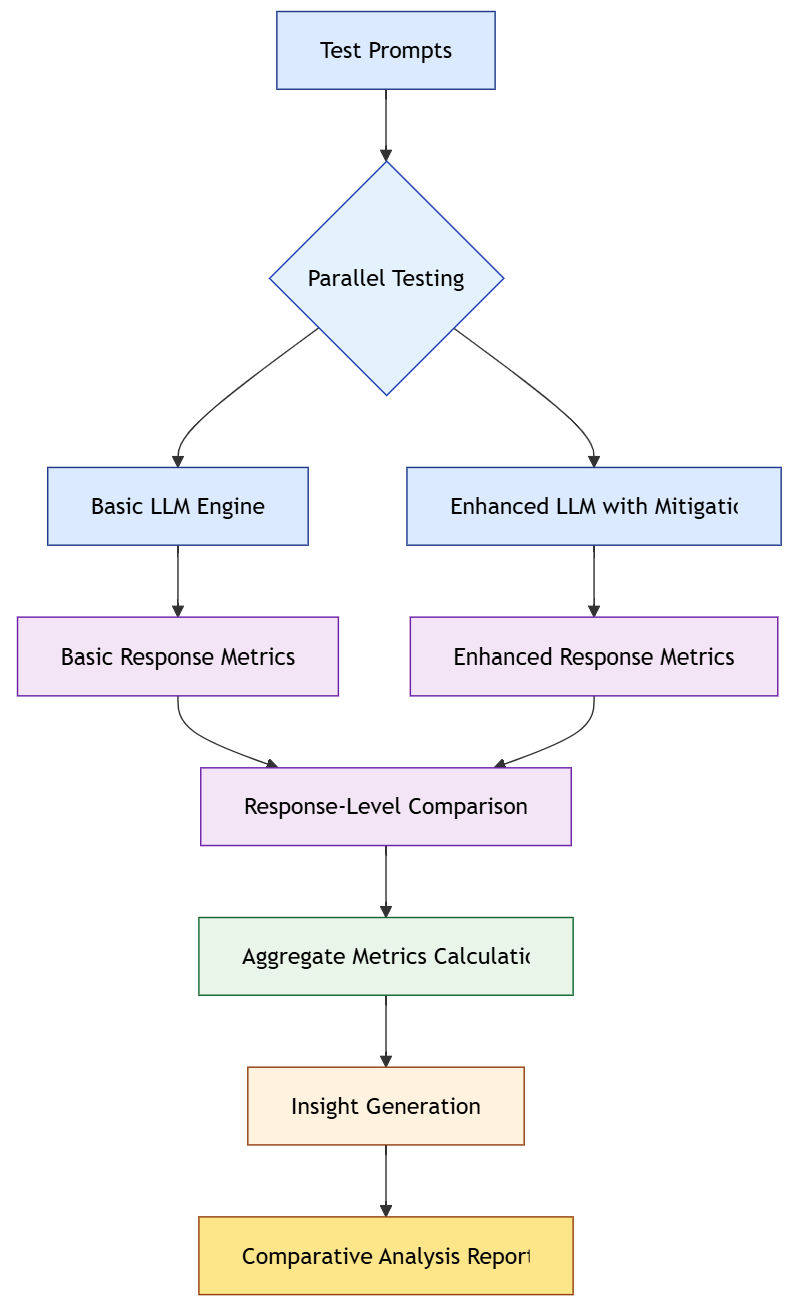

## Step-by-Step Code Breakdown
### Step 1: Multi-Engine Test Harness
- Purpose: Create a unified testing framework for different LLM configurations
- Test Components:
  - Basic LLM: The original reasoning engine without mitigation strategies
  - Enhanced LLM: The improved version with all mitigation systems active
  - Limitation Demonstrator: Reference system for understanding failure modes
  - Parallel Execution: Runs identical prompts through both systems simultaneously
  - Consistent Context: Ensures fair comparison by maintaining identical test conditions

### Step 2: Response-Level Comparison
- Purpose: Analyze individual prompt responses across multiple quality dimensions
- Comparison Metrics:
  - Confidence Improvement: Measures increase in response certainty
  - Grounding Enhancement: Quantifies better factual anchoring
  - Hallucination Reduction: Tracks decrease in fabricated information risk
  - Limitation Count: Compares number of detected issues per response
  - Improvement Summary: Provides human-readable improvement description

### Step 3: Aggregate Metrics Calculation
- Purpose: Compute overall performance differences across the entire test suite
- Statistical Analysis:
Average Confidence: Mean confidence scores across all test prompts
Grounding Score Averages: Overall improvement in factual accuracy
Hallucination Risk Reduction: Collective decrease in fabrication probability
Total Limitations: Sum of all detected issues across test runs
Improvement Percentage: Quantitative measure of overall enhancement

### Step 4: Insight Generation Engine
- Purpose: Transform quantitative metrics into actionable qualitative insights
- Insight Categories:
  - Significant Improvements: Identify areas where mitigation strategies are most effective
  - Moderate Gains: Highlight meaningful but smaller improvements
  - Limited Impact: Point out areas needing further mitigation development
  - Overall Assessment: Provide holistic evaluation of enhancement effectiveness
  - Strategic Recommendations: Suggest directions for future improvements

### Step 5: Comparative Reporting
- Purpose: Present findings in a structured, interpretable format
- Report Structure:
  - Individual prompt-by-prompt comparisons with improvement metrics
  - Aggregate performance statistics across the entire test suite
  - Qualitative insights explaining the quantitative results
  - Improvement summaries for quick assessment of mitigation effectiveness
  - Benchmarking data for future comparison studies

### Connecting to the Lecture
- Empirical Evaluation: Demonstrates the scientific approach to AI system assessment discussed in the evaluation methodologies lecture
- Quantitative Measurement: Implements the principle of using measurable metrics rather than subjective judgments for AI improvement
- A/B Testing Methodology: Shows practical application of controlled experimentation for system optimization
- Mitigation Effectiveness Analysis: Connects to the lecture topic of systematically evaluating whether proposed solutions actually work
- Multi-Dimensional Assessment: Embodies the comprehensive evaluation framework that considers confidence, grounding, and multiple limitation types      simultaneously
- Evidence-Based Improvement: Illustrates how data-driven insights should guide the development of more robust AI systems
- Benchmarking Practices: Implements standardized testing approaches for tracking AI system evolution over time

In [6]:
# EXERCISE 4: COMPARATIVE ANALYSIS SYSTEM

class LLMComparisonSystem:
    """
    System to compare different LLM configurations and their limitations
    Demonstrates the spectrum of LLM reasoning capabilities
    """
    
    def __init__(self):
        self.basic_llm = MockLLMReasoningEngine("basic-llm")
        self.enhanced_llm = EnhancedLLMWithMitigation("enhanced-llm")
        self.limitation_demo = LLMLimitationDemonstrator()
    
    def run_comparative_analysis(self, test_prompts: List[str]) -> Dict[str, Any]:
        """Run comparative analysis across different LLM configurations"""
        
        print("🔬 COMPARATIVE ANALYSIS: Basic vs Enhanced LLM")
        print("=" * 80)
        
        results = {
            "test_prompts": test_prompts,
            "basic_llm_results": [],
            "enhanced_llm_results": [],
            "comparative_metrics": {},
            "insights": []
        }
        
        for prompt in test_prompts:
            print(f"\n📝 Testing prompt: '{prompt[:80]}{'...' if len(prompt) > 80 else ''}'")
            
            # Test with basic LLM
            basic_response = self.basic_llm.reason(prompt)
            results["basic_llm_results"].append(basic_response)
            
            # Test with enhanced LLM
            enhanced_response = self.enhanced_llm.reason(prompt)
            results["enhanced_llm_results"].append(enhanced_response)
            
            # Compare responses
            comparison = self._compare_responses(basic_response, enhanced_response, prompt)
            
            print(f"  📊 Basic LLM - Confidence: {basic_response.confidence:.2f}, Issues: {len(basic_response.limitations_detected)}")
            print(f"  📊 Enhanced LLM - Confidence: {enhanced_response.confidence:.2f}, Issues: {len(enhanced_response.limitations_detected)}")
            print(f"  📈 Improvement: {comparison['improvement_summary']}")
        
        # Calculate overall metrics
        results["comparative_metrics"] = self._calculate_comparative_metrics(
            results["basic_llm_results"], 
            results["enhanced_llm_results"]
        )
        
        # Generate insights
        results["insights"] = self._generate_insights(results["comparative_metrics"])
        
        return results
    
    def _compare_responses(self, basic: LLMResponse, enhanced: LLMResponse, prompt: str) -> Dict[str, Any]:
        """Compare two LLM responses"""
        
        comparison = {
            "confidence_improvement": enhanced.confidence - basic.confidence,
            "grounding_improvement": enhanced.grounding_score - basic.grounding_score,
            "hallucination_reduction": basic.hallucination_risk - enhanced.hallucination_risk,
            "limitations_reduced": len(basic.limitations_detected) - len(enhanced.limitations_detected),
            "improvement_summary": ""
        }
        
        improvements = []
        if comparison["confidence_improvement"] > 0.1:
            improvements.append("higher confidence")
        if comparison["grounding_improvement"] > 0.1:
            improvements.append("better grounding")
        if comparison["hallucination_reduction"] > 0.1:
            improvements.append("reduced hallucination risk")
        if comparison["limitations_reduced"] > 0:
            improvements.append("fewer limitations detected")
        
        comparison["improvement_summary"] = ", ".join(improvements) if improvements else "minimal improvement"
        
        return comparison
    
    def _calculate_comparative_metrics(self, basic_results: List[LLMResponse], enhanced_results: List[LLMResponse]) -> Dict[str, Any]:
        """Calculate overall comparative metrics"""
        
        if not basic_results or not enhanced_results:
            return {}
        
        basic_avg_confidence = sum(r.confidence for r in basic_results) / len(basic_results)
        enhanced_avg_confidence = sum(r.confidence for r in enhanced_results) / len(enhanced_results)
        
        basic_avg_grounding = sum(r.grounding_score for r in basic_results) / len(basic_results)
        enhanced_avg_grounding = sum(r.grounding_score for r in enhanced_results) / len(enhanced_results)
        
        basic_avg_hallucination = sum(r.hallucination_risk for r in basic_results) / len(basic_results)
        enhanced_avg_hallucination = sum(r.hallucination_risk for r in enhanced_results) / len(enhanced_results)
        
        basic_total_limitations = sum(len(r.limitations_detected) for r in basic_results)
        enhanced_total_limitations = sum(len(r.limitations_detected) for r in enhanced_results)
        
        return {
            "average_confidence_improvement": enhanced_avg_confidence - basic_avg_confidence,
            "average_grounding_improvement": enhanced_avg_grounding - basic_avg_grounding,
            "average_hallucination_reduction": basic_avg_hallucination - enhanced_avg_hallucination,
            "total_limitations_reduction": basic_total_limitations - enhanced_total_limitations,
            "improvement_percentage": ((enhanced_avg_confidence - basic_avg_confidence) / basic_avg_confidence * 100) if basic_avg_confidence > 0 else 0
        }
    
    def _generate_insights(self, metrics: Dict[str, Any]) -> List[str]:
        """Generate insights from comparative metrics"""
        
        insights = []
        
        if metrics.get("average_confidence_improvement", 0) > 0.1:
            insights.append("Enhanced LLM shows significantly higher confidence in responses")
        
        if metrics.get("average_grounding_improvement", 0) > 0.1:
            insights.append("Mitigation strategies improve factual grounding")
        
        if metrics.get("average_hallucination_reduction", 0) > 0.1:
            insights.append("Enhanced system reduces hallucination risk")
        
        if metrics.get("total_limitations_reduction", 0) > 0:
            insights.append("Fewer limitations detected with enhanced system")
        
        improvement_pct = metrics.get("improvement_percentage", 0)
        if improvement_pct > 20:
            insights.append(f"Overall improvement of {improvement_pct:.1f}% in reasoning quality")
        elif improvement_pct > 10:
            insights.append("Moderate improvement in reasoning quality achieved")
        else:
            insights.append("Limited improvement - more advanced mitigation may be needed")
        
        return insights


### Short Description
This code provides a complete educational demonstration that showcases LLM reasoning capabilities, limitations, mitigation strategies, and comparative analysis in a structured format. It serves as both a live demonstration system and a comprehensive exercise framework for students learning about agentic AI systems.

### Code Logic and Flow: High-Level Overview
The main demonstration orchestrates all previously built systems into a progressive learning experience that starts with basic reasoning capabilities, moves through limitation exposure, demonstrates mitigation effectiveness, and concludes with comparative analysis. The student exercises provide structured learning paths for hands-on experimentation with reasoning engines, limitation analysis, mitigation development, and real-world applications.

### Visual Flowchart
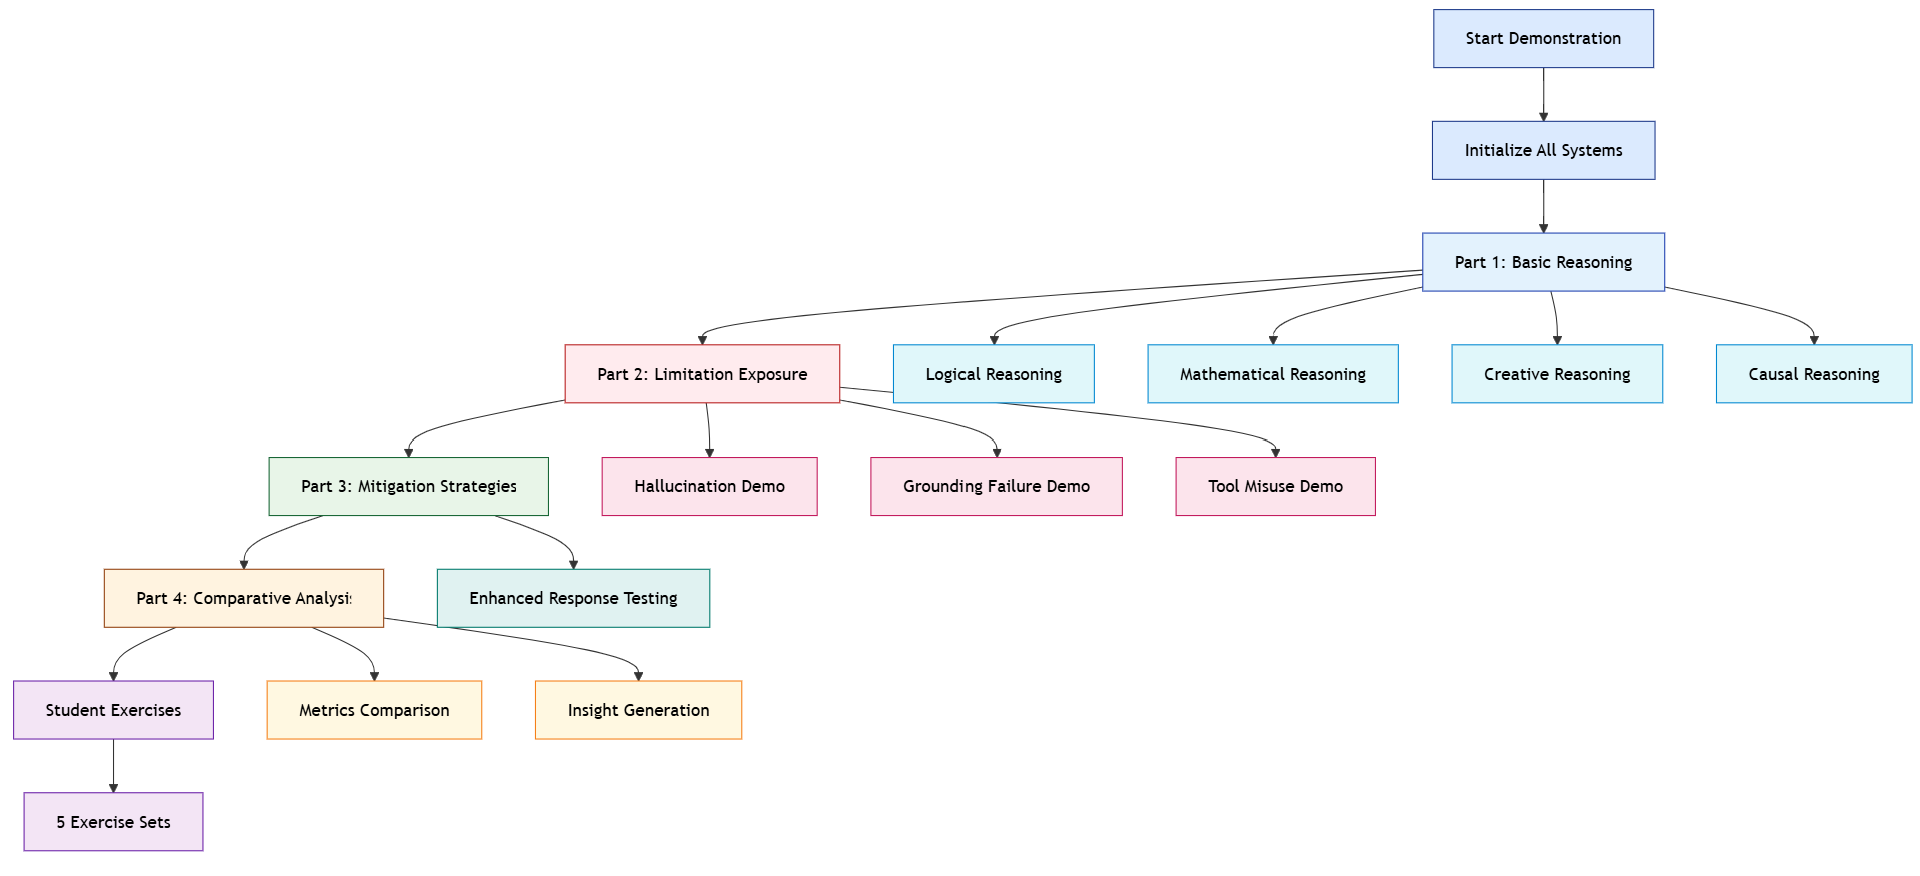

## Step-by-Step Code Breakdown
### Step 1: System Initialization and Setup
- Purpose: Prepare all demonstration components for coordinated execution
- Initialization Process:
  - Creates basic LLM reasoning engine with standard capabilities
  - Instantiates limitation demonstration system for failure mode exposure
  - Initializes enhanced LLM with all mitigation strategies active
  - Sets up comparative analysis system for performance evaluation
  - Establishes consistent testing environment across all demonstrations

### Step 2: Progressive Demonstration Structure
- Purpose: Guide learners through increasingly complex concepts in logical sequence
- Four-Part Structure:
  - Basic Capabilities: Show fundamental reasoning across logical, mathematical, creative, and causal domains
  - Limitation Exposure: Systematically demonstrate hallucinations, grounding failures, and tool misuse
  - Mitigation Strategies: Show enhanced system handling previously problematic scenarios
  - Comparative Analysis: Provide quantitative evidence of improvement through metrics and insights

### Step 3: Multi-Domain Reasoning Demonstration
- Purpose: Showcase LLM capabilities across different reasoning types
- Demonstration Categories:
  - Logical Reasoning: Deductive reasoning with categorical statements
  - Mathematical Reasoning: Calculations with tool integration
  - Creative Reasoning: Solution design for complex problems
  - Causal Reasoning: Analysis of cause-effect relationships in real-world events
  - Confidence Tracking: Display confidence and grounding scores for each response

### Step 4: Comprehensive Limitation Exposure
- Purpose: Provide controlled exposure to common LLM failure modes
- Demonstration Strategy:
  - Hallucination Scenarios: Test with requests for specific, potentially non-existent information
  - Grounding Failure Cases: Use current events and real-time data requests
  - Tool Misuse Examples: Demonstrate inappropriate tool selection and application
  - Analysis Integration: Show limitation detection and severity assessment

### Step 5: Structured Student Learning Path
- Purpose: Provide guided hands-on experimentation opportunities
- Five Exercise Sets:
  - Reasoning Understanding: Engine customization and capability analysis
  - Limitation Analysis: Scenario design and severity assessment
  - Mitigation Development: Strategy implementation and effectiveness testing
  - Real-World Applications: Domain-specific risk analysis and solution design
  - Advanced Patterns: New reasoning type development and complex problem-solving

### Connecting to the Lecture
- Progressive Learning Design: Implements the educational principle of building complexity gradually from basic concepts to advanced applications
- Hands-On Experimentation: Embodies the "learning by doing" approach emphasized in technical education for AI systems
- Comprehensive System Understanding: Demonstrates how to analyze AI systems holistically across capabilities, limitations, and improvements
- Real-World Relevance: Connects theoretical AI concepts to practical applications through domain-specific exercises
- Critical Thinking Development: Encourages students to move beyond surface-level understanding to deep system analysis and improvement
- Iterative Improvement Mindset: Teaches the process of identifying problems, developing solutions, and measuring effectiveness
- Multi-Perspective Analysis: Shows the importance of evaluating AI systems from different angles: capability, reliability, and practical utility

In [7]:
# MAIN DEMONSTRATION AND STUDENT EXERCISES

def main_demonstration():
    """Main demonstration of LLMs as reasoning engines"""
    
    print("🧠 LLMs AS REASONING ENGINES - COMPREHENSIVE DEMONSTRATION")
    print("=" * 80)
    
    # Initialize systems
    basic_llm = MockLLMReasoningEngine("demo-llm-v1")
    limitation_demo = LLMLimitationDemonstrator()
    enhanced_llm = EnhancedLLMWithMitigation("enhanced-demo-llm")
    comparison_system = LLMComparisonSystem()
    
    # Part 1: Basic LLM Reasoning Demonstration
    print("\n1️⃣ BASIC LLM REASONING CAPABILITIES")
    print("-" * 50)
    
    demo_prompts = [
        "If all cats are mammals and all mammals are animals, what can we conclude about cats?",
        "Calculate the compound interest on $1000 at 5% annual rate for 3 years",
        "Design a creative solution for reducing plastic waste in oceans",
        "What caused the 2008 financial crisis and what were its main effects?"
    ]
    
    for prompt in demo_prompts:
        print(f"\n🔍 Prompt: {prompt}")
        response = basic_llm.reason(prompt, tools_available=["calculator", "search"])
        print(f"🤖 Response: {response.content}")
        print(f"📊 Confidence: {response.confidence:.2f} | Grounding: {response.grounding_score:.2f}")
        print(f"⚠️ Issues: {[lt.value for lt in response.limitations_detected]}")
    
    # Part 2: Limitation Demonstrations
    print("\n\n2️⃣ LLM LIMITATIONS DEMONSTRATION")
    print("-" * 50)
    
    for limitation_type in [LimitationType.HALLUCINATION, LimitationType.GROUNDING_FAILURE, LimitationType.TOOL_MISUSE]:
        limitation_demo.demonstrate_limitation(limitation_type, basic_llm)
    
    # Part 3: Enhanced LLM with Mitigations
    print("\n\n3️⃣ ENHANCED LLM WITH MITIGATION STRATEGIES")
    print("-" * 50)
    
    mitigation_test_prompts = [
        "What did Apple announce at their latest event yesterday?",  # Grounding test
        "Calculate the emotional ROI of employee wellness programs",  # Tool misuse test
        "Tell me the exact market share statistics for cloud computing in 2024"  # Hallucination test
    ]
    
    for prompt in mitigation_test_prompts:
        print(f"\n🔍 Testing: {prompt}")
        enhanced_response = enhanced_llm.reason(prompt, tools_available=["calculator", "search"])
        print(f"🛡️ Enhanced Response: {enhanced_response.content}")
        print(f"📊 Confidence: {enhanced_response.confidence:.2f}")
    
    # Part 4: Comparative Analysis
    print("\n\n4️⃣ COMPARATIVE ANALYSIS")
    print("-" * 50)
    
    comparison_results = comparison_system.run_comparative_analysis([
        "What are the main factors contributing to climate change?",
        "Calculate the best investment strategy for a 25-year-old with $50,000",
        "Explain quantum computing and its potential applications"
    ])
    
    print(f"\n📈 COMPARATIVE RESULTS:")
    metrics = comparison_results["comparative_metrics"]
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.3f}")
    
    print(f"\n💡 KEY INSIGHTS:")
    for insight in comparison_results["insights"]:
        print(f"  • {insight}")

def student_exercises():
    """Comprehensive student exercises"""
    
    print("\n" + "=" * 80)
    print("STUDENT EXERCISES - LLMs AS REASONING ENGINES")
    print("=" * 80)
    
    print("""
    📚 EXERCISE SET 1: UNDERSTANDING LLM REASONING
    
    1. Create your own MockLLMReasoningEngine with different capability scores
    2. Test it with various reasoning types and analyze the outputs
    3. Identify which reasoning types your LLM handles best/worst
    4. Document the relationship between reasoning complexity and confidence
    
    📚 EXERCISE SET 2: LIMITATION ANALYSIS
    
    1. Design 5 new scenarios for each limitation type
    2. Test them with the LLMLimitationDemonstrator
    3. Analyze which limitations are most problematic for different tasks
    4. Create a "limitation severity matrix" for different domains
    
    📚 EXERCISE SET 3: MITIGATION STRATEGIES
    
    1. Implement a new mitigation strategy (e.g., multi-LLM consensus)
    2. Add it to the EnhancedLLMWithMitigation class
    3. Test its effectiveness against specific limitations
    4. Compare your mitigation with existing ones
    
    📚 EXERCISE SET 4: REAL-WORLD APPLICATIONS
    
    1. Choose a specific domain (medical, legal, financial, educational)
    2. Identify domain-specific LLM limitations and risks
    3. Design appropriate mitigation strategies for that domain
    4. Create test scenarios that reflect real-world usage
    
    📚 EXERCISE SET 5: ADVANCED REASONING PATTERNS
    
    1. Implement new reasoning types (e.g., ethical, emotional, strategic)
    2. Create reasoning chains that combine multiple types
    3. Develop metrics to evaluate reasoning quality
    4. Test on complex, multi-step reasoning problems
    """)

if __name__ == "__main__":
    main_demonstration()
    student_exercises()

🧠 LLMs AS REASONING ENGINES - COMPREHENSIVE DEMONSTRATION
🧠 Initialized demo-llm-v1 with reasoning capabilities
🧠 Initialized enhanced-demo-llm with reasoning capabilities
🛡️  Initialized enhanced-demo-llm with mitigation strategies
🧠 Initialized basic-llm with reasoning capabilities
🧠 Initialized enhanced-llm with reasoning capabilities
🛡️  Initialized enhanced-llm with mitigation strategies

1️⃣ BASIC LLM REASONING CAPABILITIES
--------------------------------------------------

🔍 Prompt: If all cats are mammals and all mammals are animals, what can we conclude about cats?

🔍 LLM Processing: 'If all cats are mammals and all mammals are animals, what can we conclude about cats?'
  ✓ Completed logical reasoning
  ✓ Completed logical reasoning
🤖 Response: Based on reasoning analysis: Logical conclusion derived I'm quite confident in this reasoning.
📊 Confidence: 0.94 | Grounding: 0.00
⚠️ Issues: []

🔍 Prompt: Calculate the compound interest on $1000 at 5% annual rate for 3 years

🔍 LLM 